In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.pd_utils import get_life_times
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max, fig_bottleneck_std, fig_bottleneck_median

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# embedding+mask loading if procrustes

In [ ]:
embd_tasic_orange = np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_tasic_orange.npy"))


# embedding loading and mask making if not procrustes

In [34]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "tasic",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [91]:
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

In [93]:
mask_Pvalb = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Pvalb")
mask_Sst = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sst")
mask_orange = np.maximum(mask_Pvalb, mask_Sst)

In [8]:
print("dataset size of orange is ", sum(mask_orange))

dataset size of orange is  5113


# load data!

In [ ]:
dataset = "tasic_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


# bottleneck distance

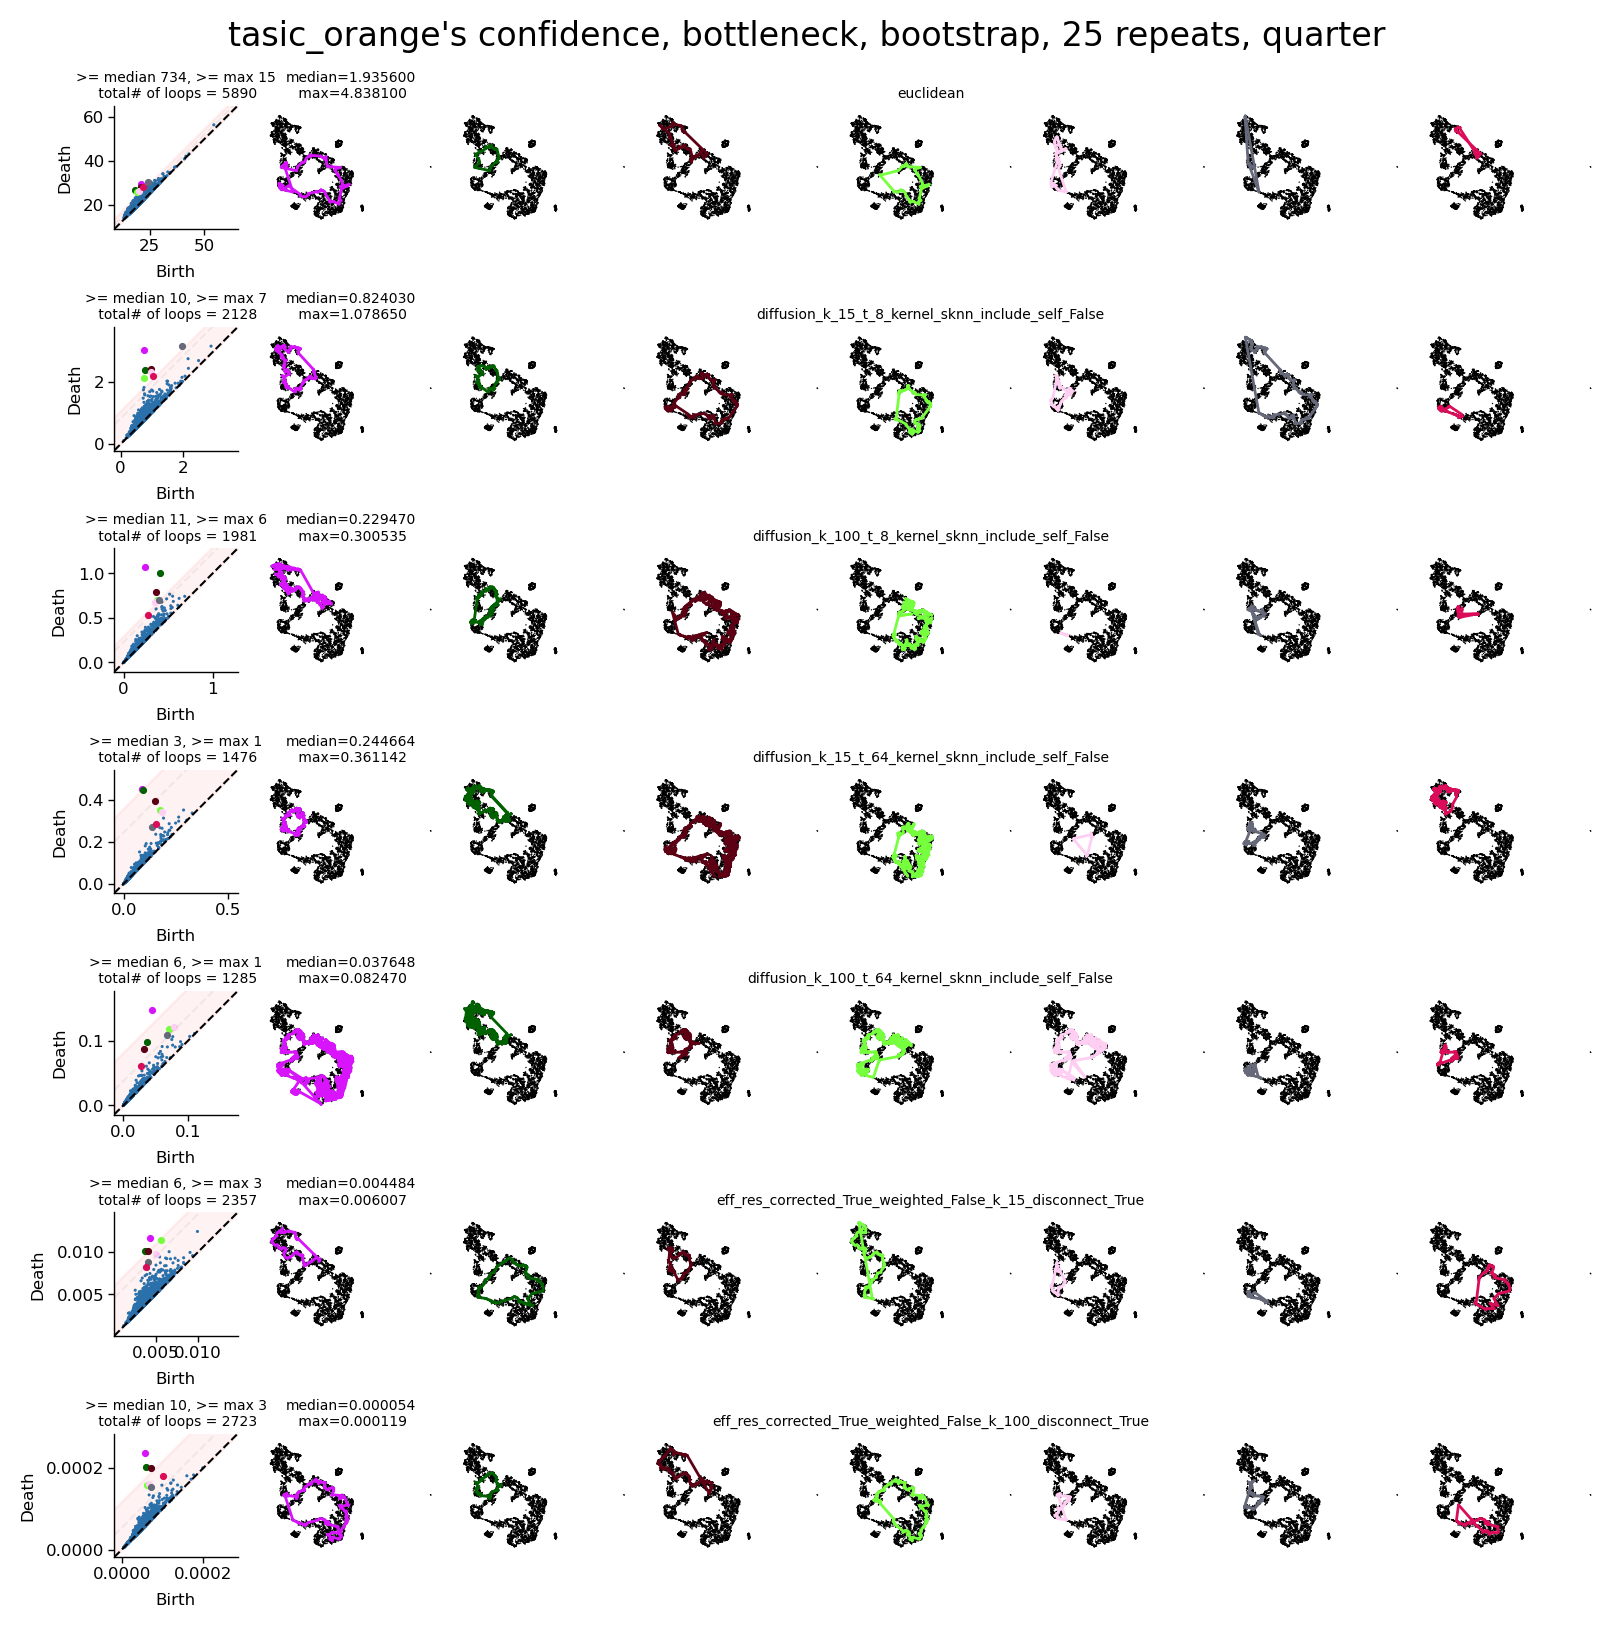

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="bootstrap", save = True)

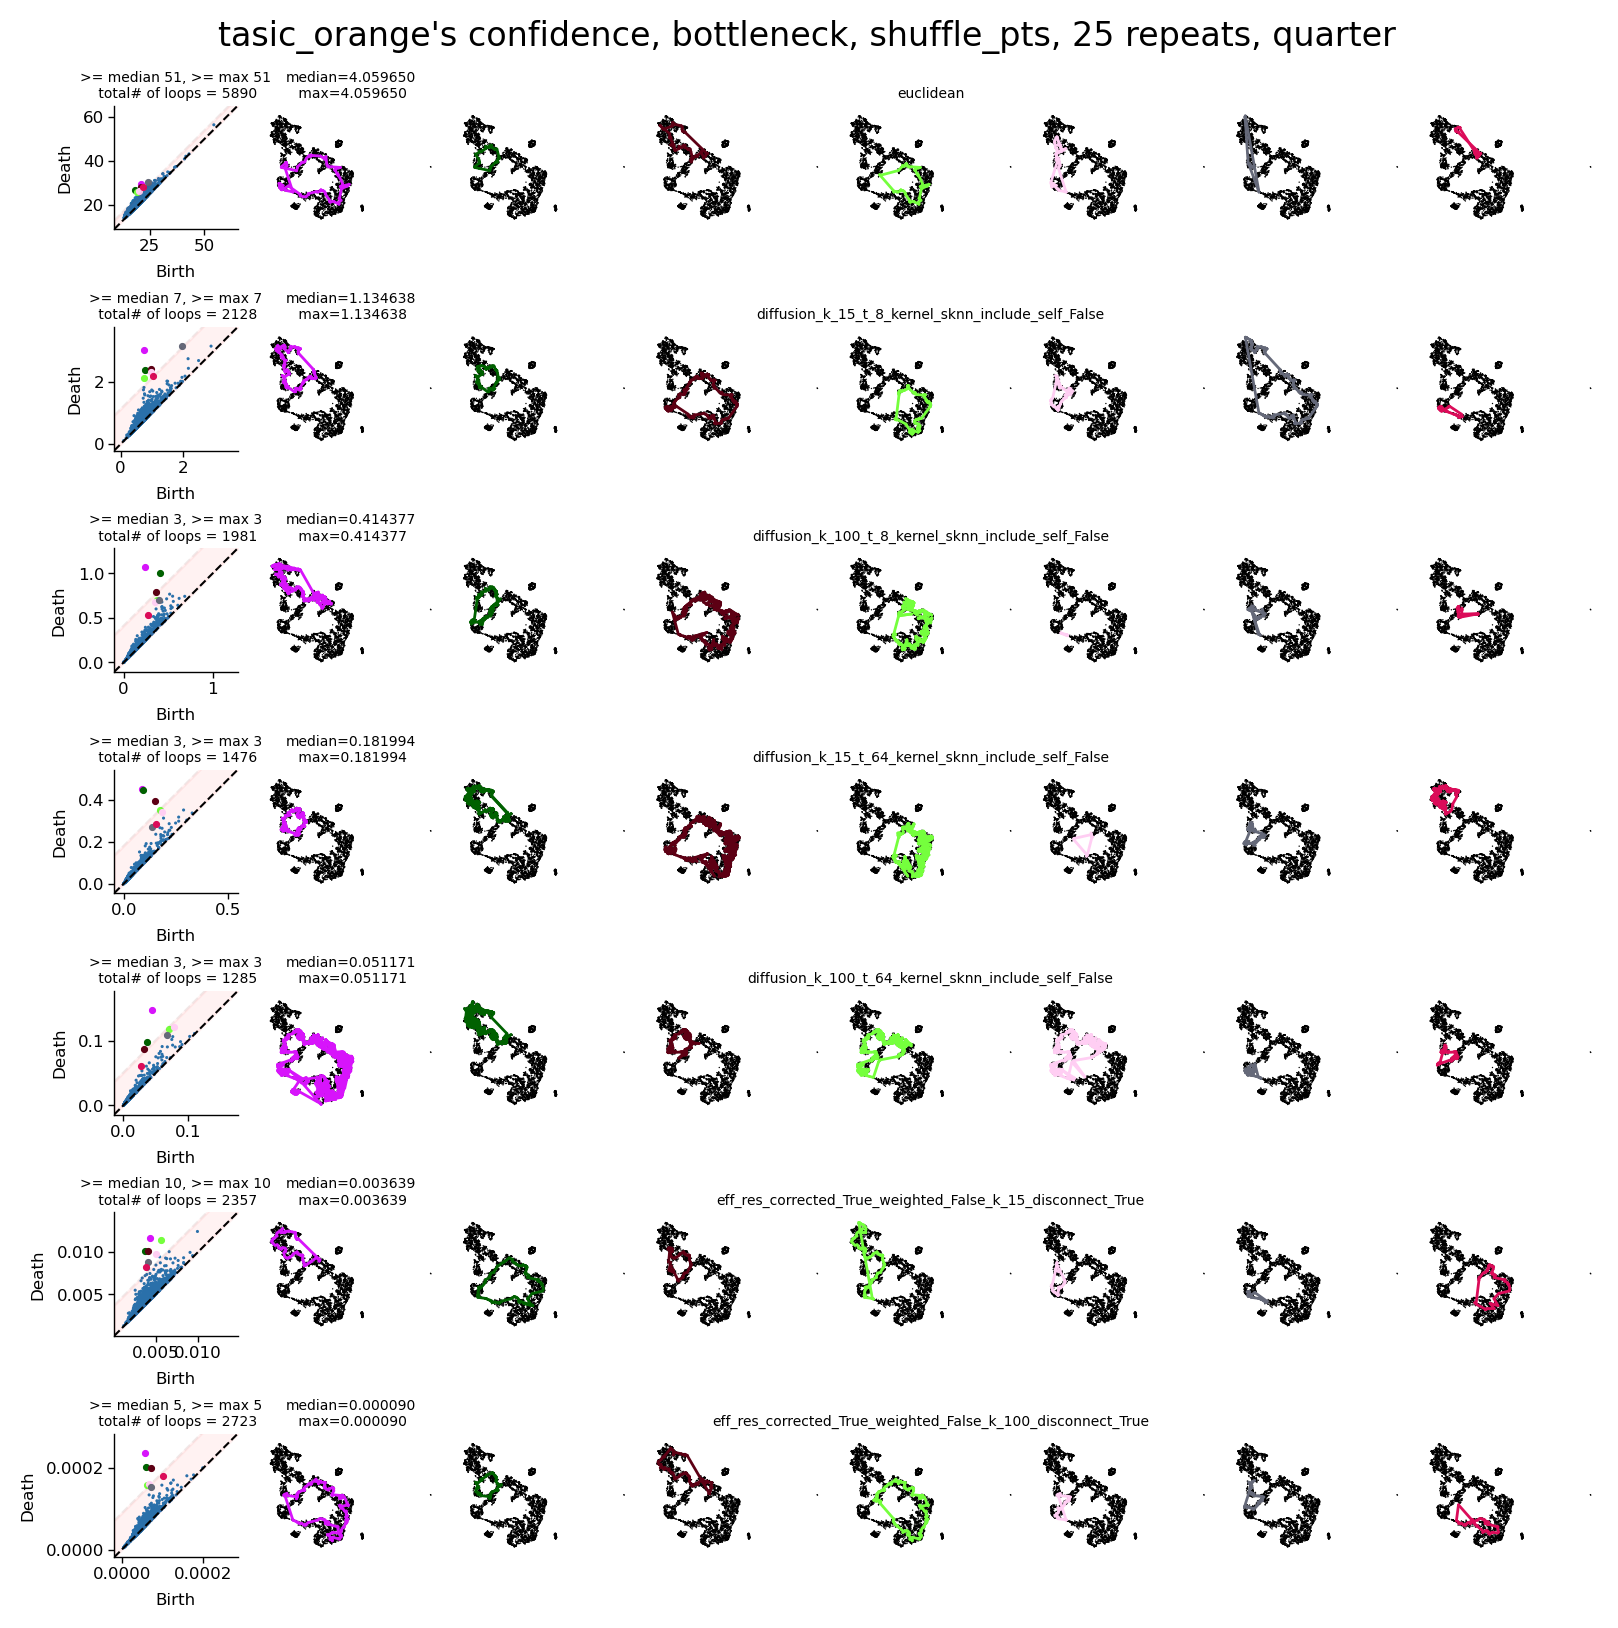

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="shuffle_pts", save = True)

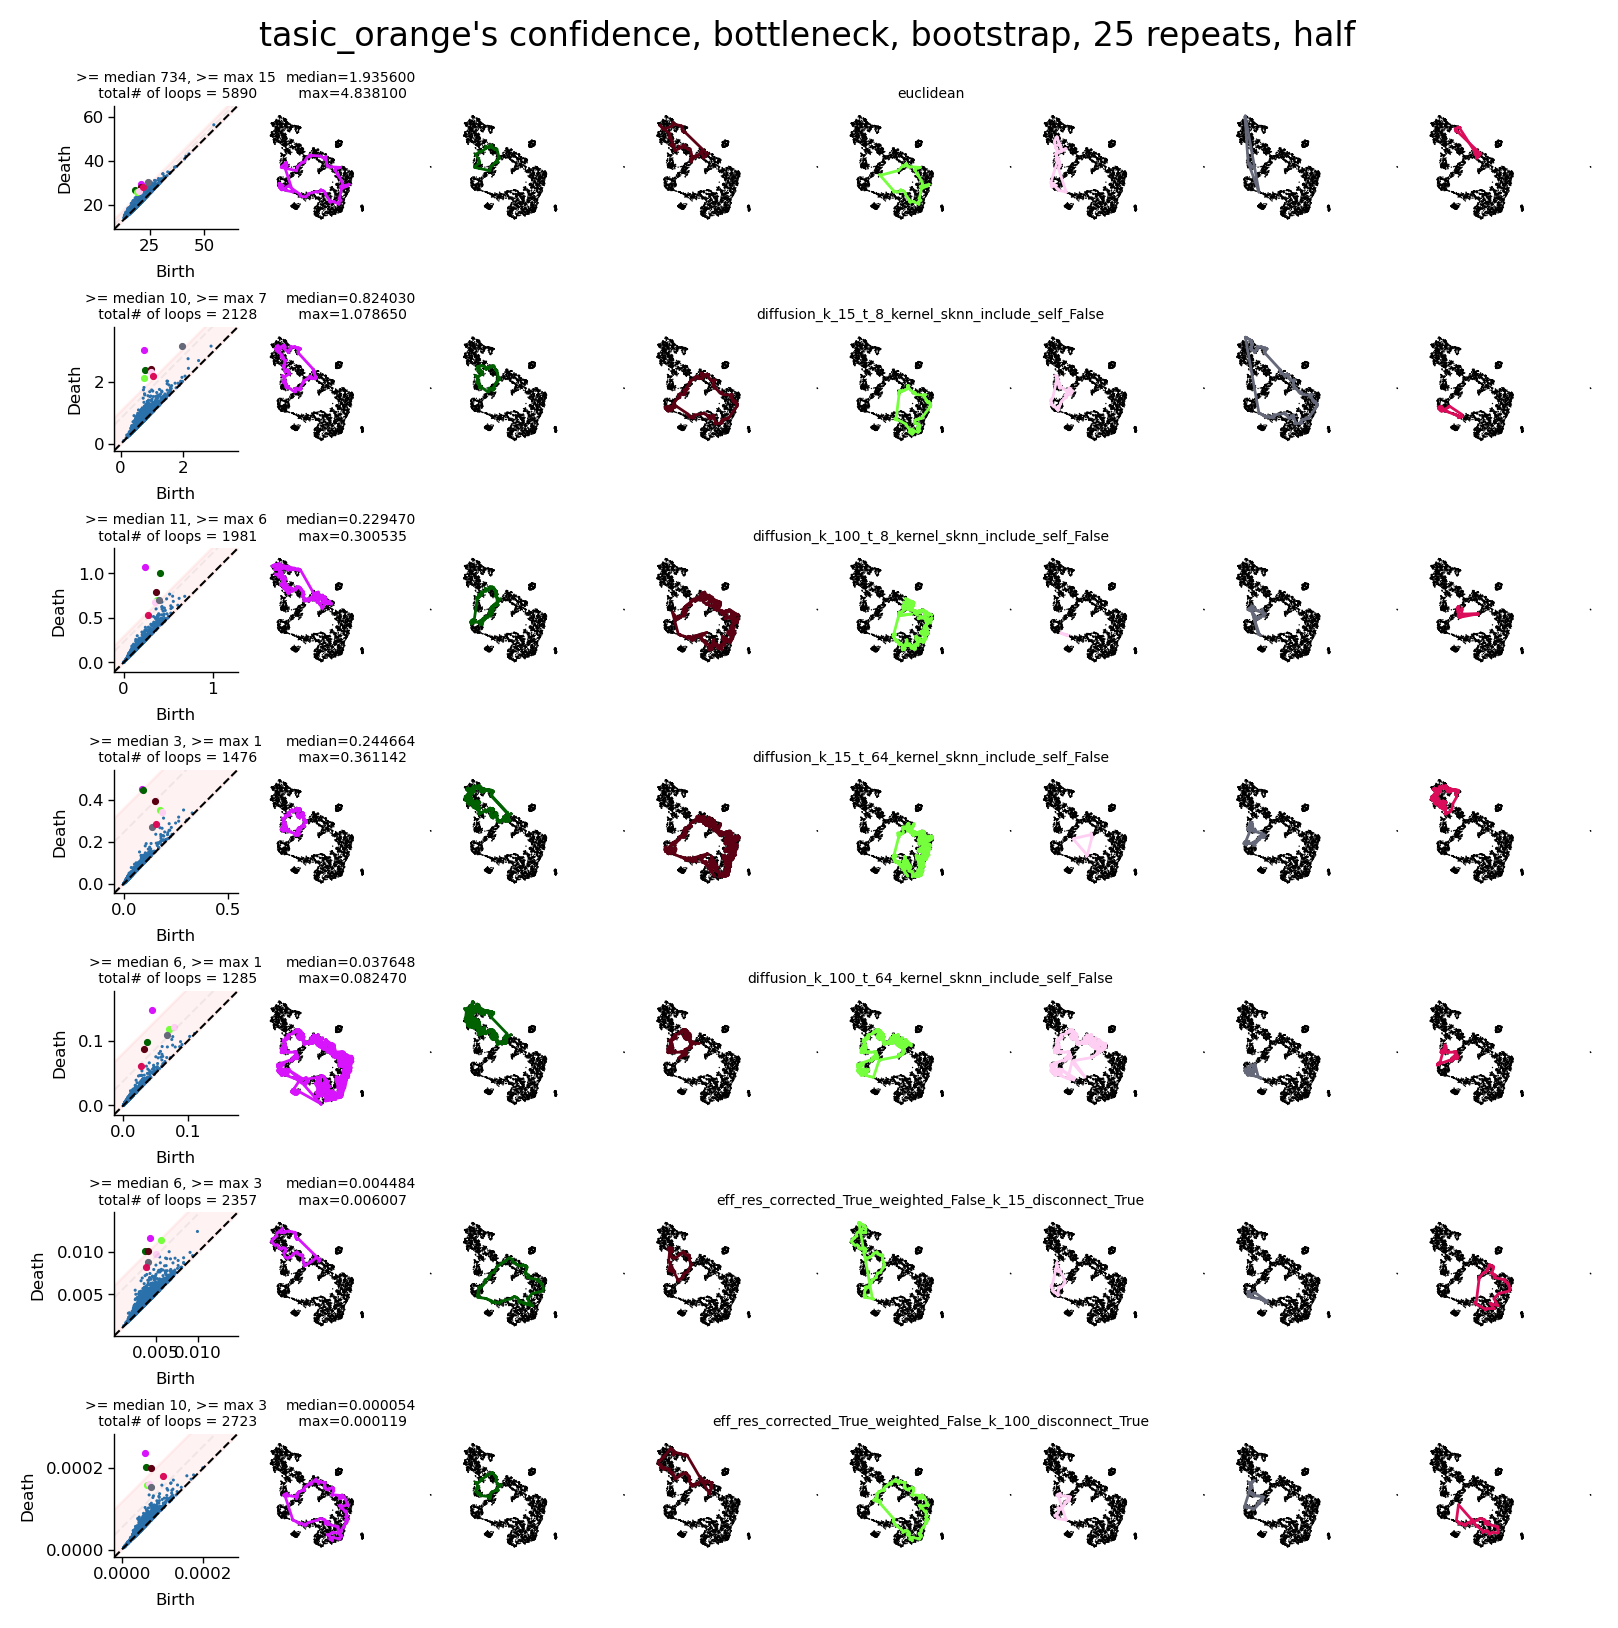

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="bootstrap", ratio = "half", save = False)

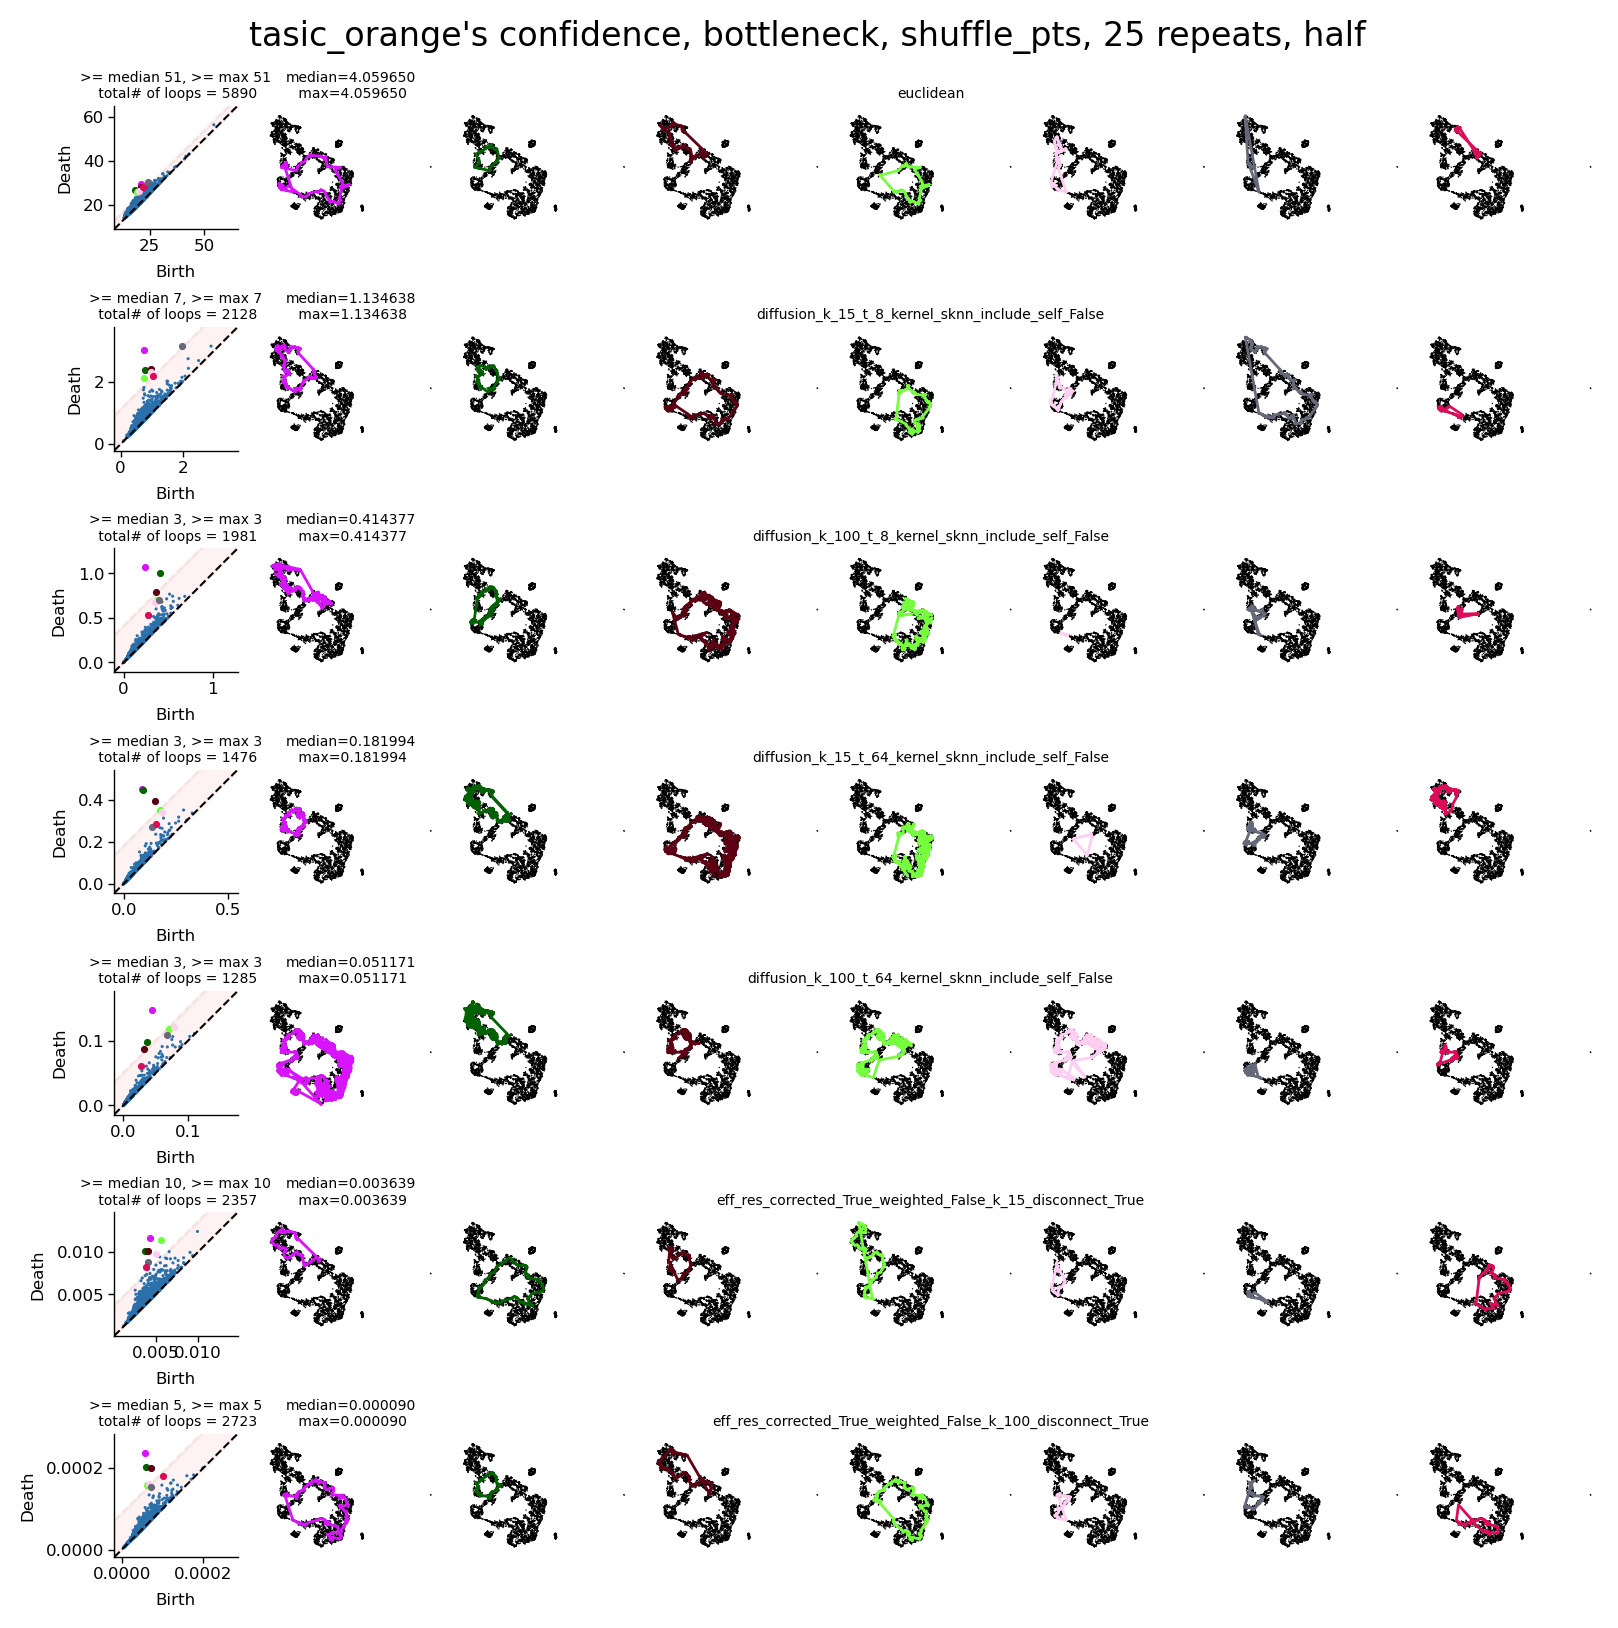

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="shuffle_pts", ratio = "half", save = False)

## so it turns out the distance with a quarter of loops is exactly the same with half of the loops, but MUCH faster. will just use a quarter in future.

In [ ]:
for ratio in ["quarter", "half"]:
    for method in ["bootstrap", "shuffle_pts"]:
        for i, distance in enumerate(distances.keys()):
            for j, full_dist in enumerate(all_res_before[distance]):
                try:
                    d = load_dict(os.path.join(root_path,"tasic_orange", f"bottleneck_dists_{method}_{ratio}_{full_dist}.pkl"))
                    print(d)
                except FileNotFoundError:
                    print(f"bottleneck_dists_{method}_{ratio}_{full_dist} didnt exist")

{'bottleneck': array([1.6528 , 2.0234 , 1.8872 , 1.5009 , 2.14355, 1.6507 , 1.8187 ,
       2.6608 , 2.9034 , 1.9974 , 1.4865 , 2.2286 , 2.3048 , 2.0845 ,
       2.9039 , 2.38815, 1.41   , 1.8062 , 1.8905 , 1.5967 , 1.9356 ,
       1.9074 , 2.1871 , 4.8381 , 1.7243 ])}
{'bottleneck': array([1.02578 , 0.77769 , 0.68652 , 0.72052 , 0.668175, 0.7918  ,
       0.71276 , 0.91058 , 1.07865 , 0.81757 , 0.945155, 0.79568 ,
       0.666577, 0.75564 , 0.61299 , 0.82403 , 0.85377 , 0.83921 ,
       0.87002 , 0.84639 , 0.92685 , 0.84595 , 0.742525, 0.89828 ,
       0.85773 ])}
{'bottleneck': array([0.250781, 0.126841, 0.19005 , 0.297161, 0.087855, 0.24928 ,
       0.214751, 0.25471 , 0.186881, 0.206018, 0.300535, 0.215922,
       0.167871, 0.193285, 0.231961, 0.26455 , 0.22979 , 0.293178,
       0.229461, 0.22947 , 0.29485 , 0.129931, 0.215131, 0.249441,
       0.290551])}
{'bottleneck': array([0.272238 , 0.1908265, 0.261379 , 0.2785505, 0.137485 , 0.227014 ,
       0.253679 , 0.208793 , 0.244664 

# a quarter thingy investigation

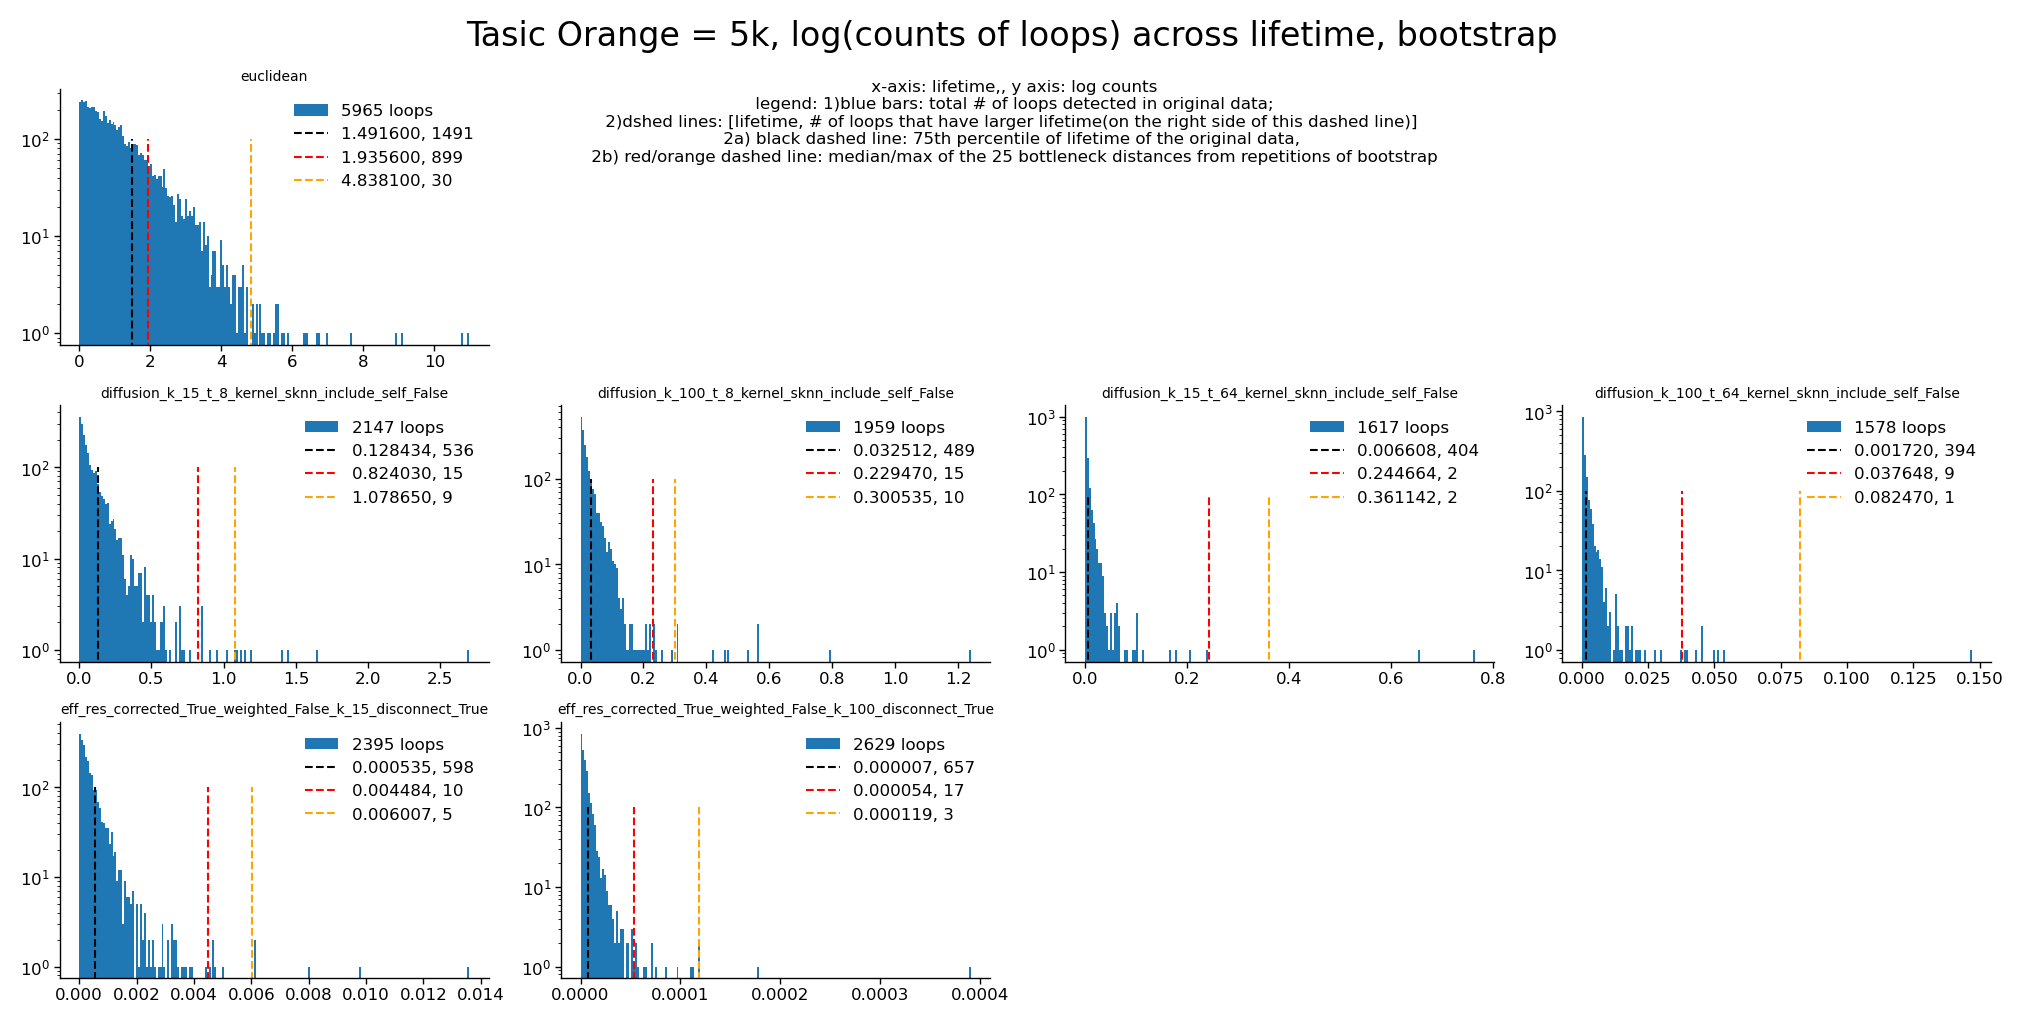

In [ ]:
method = "bootstrap"
# method = "shuffle_pts"
ratio = "quarter"

fig, ax = plt.subplots(3,4, figsize=(10, 5))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,1] - life_array[:,0]
        
        num = len(life_array)
              
        tryit = load_dict(os.path.join(root_path,"tasic_orange", f"bottleneck_dists_{method}_{ratio}_{full_dist}.pkl"))

        bottleneck_dists = list(tryit.values())[0]
        life_median = np.median(bottleneck_dists)
        life_max = np.max(bottleneck_dists)
        
        geq_median = np.sum(np.array(reference_life_long) >= life_median)
        geq_max = np.sum(np.array(reference_life_long) >= life_max)
               
        longest_original = np.max(reference_life_long)
        list_bin = np.max(reference_life_long)
        quarter_v = np.percentile(reference_life_long, 75)
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), log = True, label = f"{num} loops" )
        ax[i][j].vlines(x = quarter_v, ymin=0.0, ymax=100, color='black', linestyle='--',label = "{:3f}".format(quarter_v) + f", {int(np.floor(num/4))}")
        ax[i][j].vlines(x = life_median, ymin=0.0, ymax=100, color='red', linestyle='--',label = "{:3f}".format(life_median)+ f", {geq_median}")
        ax[i][j].vlines(x = life_max, ymin=0.0, ymax=100, color='orange', linestyle='--',label = "{:3f}".format(life_max)+ f", {geq_max}")
        ax[i][j].set_title(f"{full_dist}",  fontsize = 5)
        
        ax[i][j].legend(loc="upper right", frameon=False)

        # ax[i][j].set_xticklabels(np.linspace(0.0, longest_original, 17), rotation = 90)
        
fig.suptitle(f"Tasic Orange = 5k, log(counts of loops) across lifetime, {method}"
            , fontsize = 12)       

fig.text(0.5, 0.85,  f"\n x-axis: lifetime,, y axis: log counts"
             + f"\n legend: 1)blue bars: total # of loops detected in original data;"
             + f"\n 2)dshed lines: [lifetime, # of loops that have larger lifetime(on the right side of this dashed line)] "
             + f"\n 2a) black dashed line: 75th percentile of lifetime of the original data, "
             + f"\n 2b) red/orange dashed line: median/max of the 25 bottleneck distances from repetitions of {method}", ha='center', fontsize=6)
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"lifetime_logcounts_{method}.png"), dpi=300)

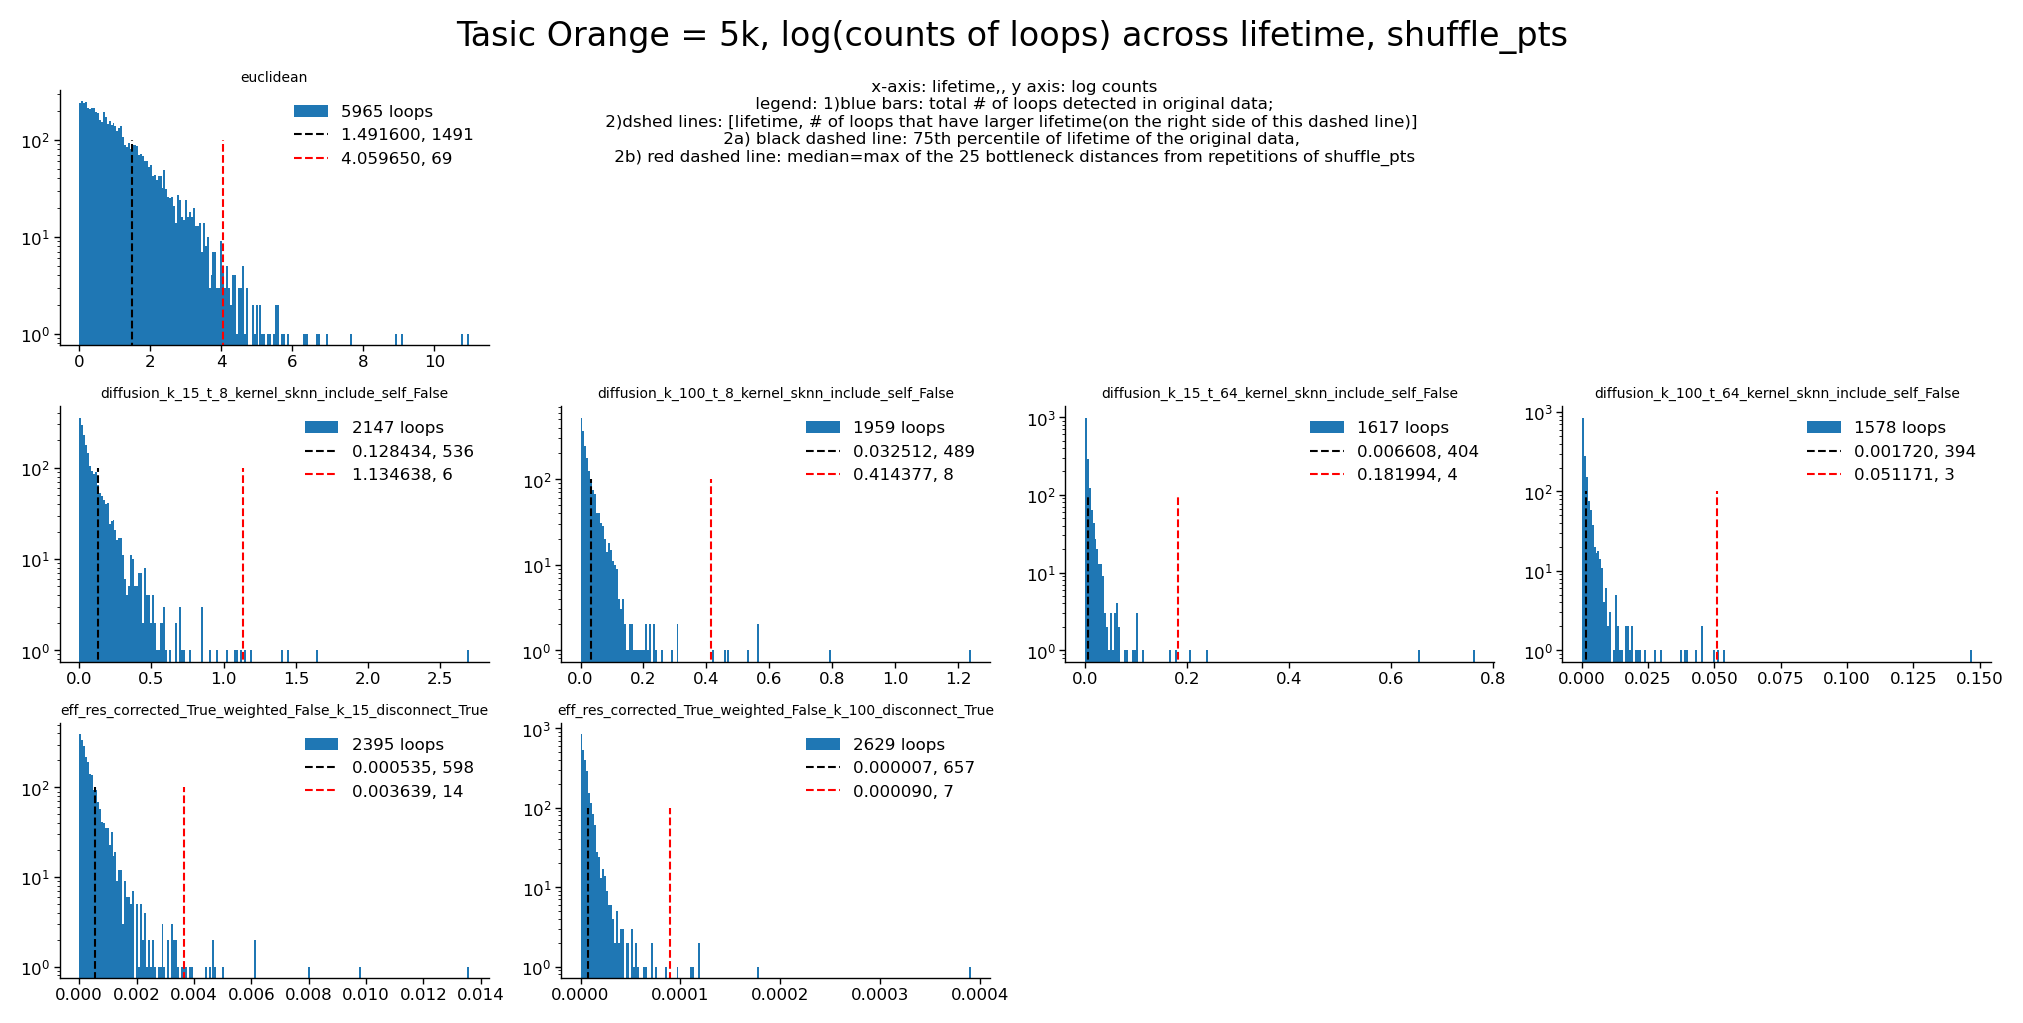

In [ ]:
# method = "bootstrap"
method = "shuffle_pts"
ratio = "quarter"

fig, ax = plt.subplots(3,4, figsize=(10, 5))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,1] - life_array[:,0]
        
        num = len(life_array)
              
        tryit = load_dict(os.path.join(root_path,"tasic_orange", f"bottleneck_dists_{method}_{ratio}_{full_dist}.pkl"))

        bottleneck_dists = list(tryit.values())[0]
        life_median = np.median(bottleneck_dists)
        life_max = np.max(bottleneck_dists)
        
        geq_median = np.sum(np.array(reference_life_long) >= life_median)
        geq_max = np.sum(np.array(reference_life_long) >= life_max)
               
        longest_original = np.max(reference_life_long)
        list_bin = np.max(reference_life_long)
        quarter_v = np.percentile(reference_life_long, 75)
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), log = True, label = f"{num} loops" )
        ax[i][j].vlines(x = quarter_v, ymin=0.0, ymax=100, color='black', linestyle='--',label = "{:3f}".format(quarter_v) + f", {int(np.floor(num/4))}")
        ax[i][j].vlines(x = life_median, ymin=0.0, ymax=100, color='red', linestyle='--',label = "{:3f}".format(life_median)+ f", {geq_median}")
        ax[i][j].set_title(f"{full_dist}",  fontsize = 5)
        
        ax[i][j].legend(loc="upper right", frameon=False)

        # ax[i][j].set_xticklabels(np.linspace(0.0, longest_original, 17), rotation = 90)
        
fig.suptitle(f"Tasic Orange = 5k, log(counts of loops) across lifetime, {method}"
            , fontsize = 12)       

fig.text(0.5, 0.85,  f"\n x-axis: lifetime,, y axis: log counts"
             + f"\n legend: 1)blue bars: total # of loops detected in original data;"
             + f"\n 2)dshed lines: [lifetime, # of loops that have larger lifetime(on the right side of this dashed line)] "
             + f"\n 2a) black dashed line: 75th percentile of lifetime of the original data, "
             + f"\n 2b) red dashed line: median=max of the 25 bottleneck distances from repetitions of {method}", ha='center', fontsize=6)


plt.show()
fig.savefig(os.path.join(get_path("figures"), f"lifetime_logcounts_{method}.png"), dpi=300)

# checking if in shuffle_pts the median and the max are the same or just similar. Its okay to be similar, but shouldn't be the same


In [ ]:
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        d = load_dict(os.path.join(root_path,"tasic_orange", f"checkup_dists_shuffle_pts_{full_dist}.pkl"))
        n_loops = [len(d["dgms"][i]['dgms'][1]) for  i in range(25)]
        print(len(set(n_loops)) == 1)


False
False
False
False
False
False
False


In [ ]:
bottleneck_sanity = []
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        d = load_dict(os.path.join(root_path,"tasic_orange", f"bottleneck_dists_shuffle_pts_quarter_{full_dist}.pkl"))
        print(set(d['bottleneck']))
        bottleneck_sanity.append(d['bottleneck'][0])
        # print(len(set(d['bottleneck'])))

{4.0596499999999995}
{1.1346384999999999}
{0.41437650000000004}
{0.18199385}
{0.051171049999999996}
{0.0036393750000000002}
{8.99477e-05}


# fig_bottleneck_max of bootstrap

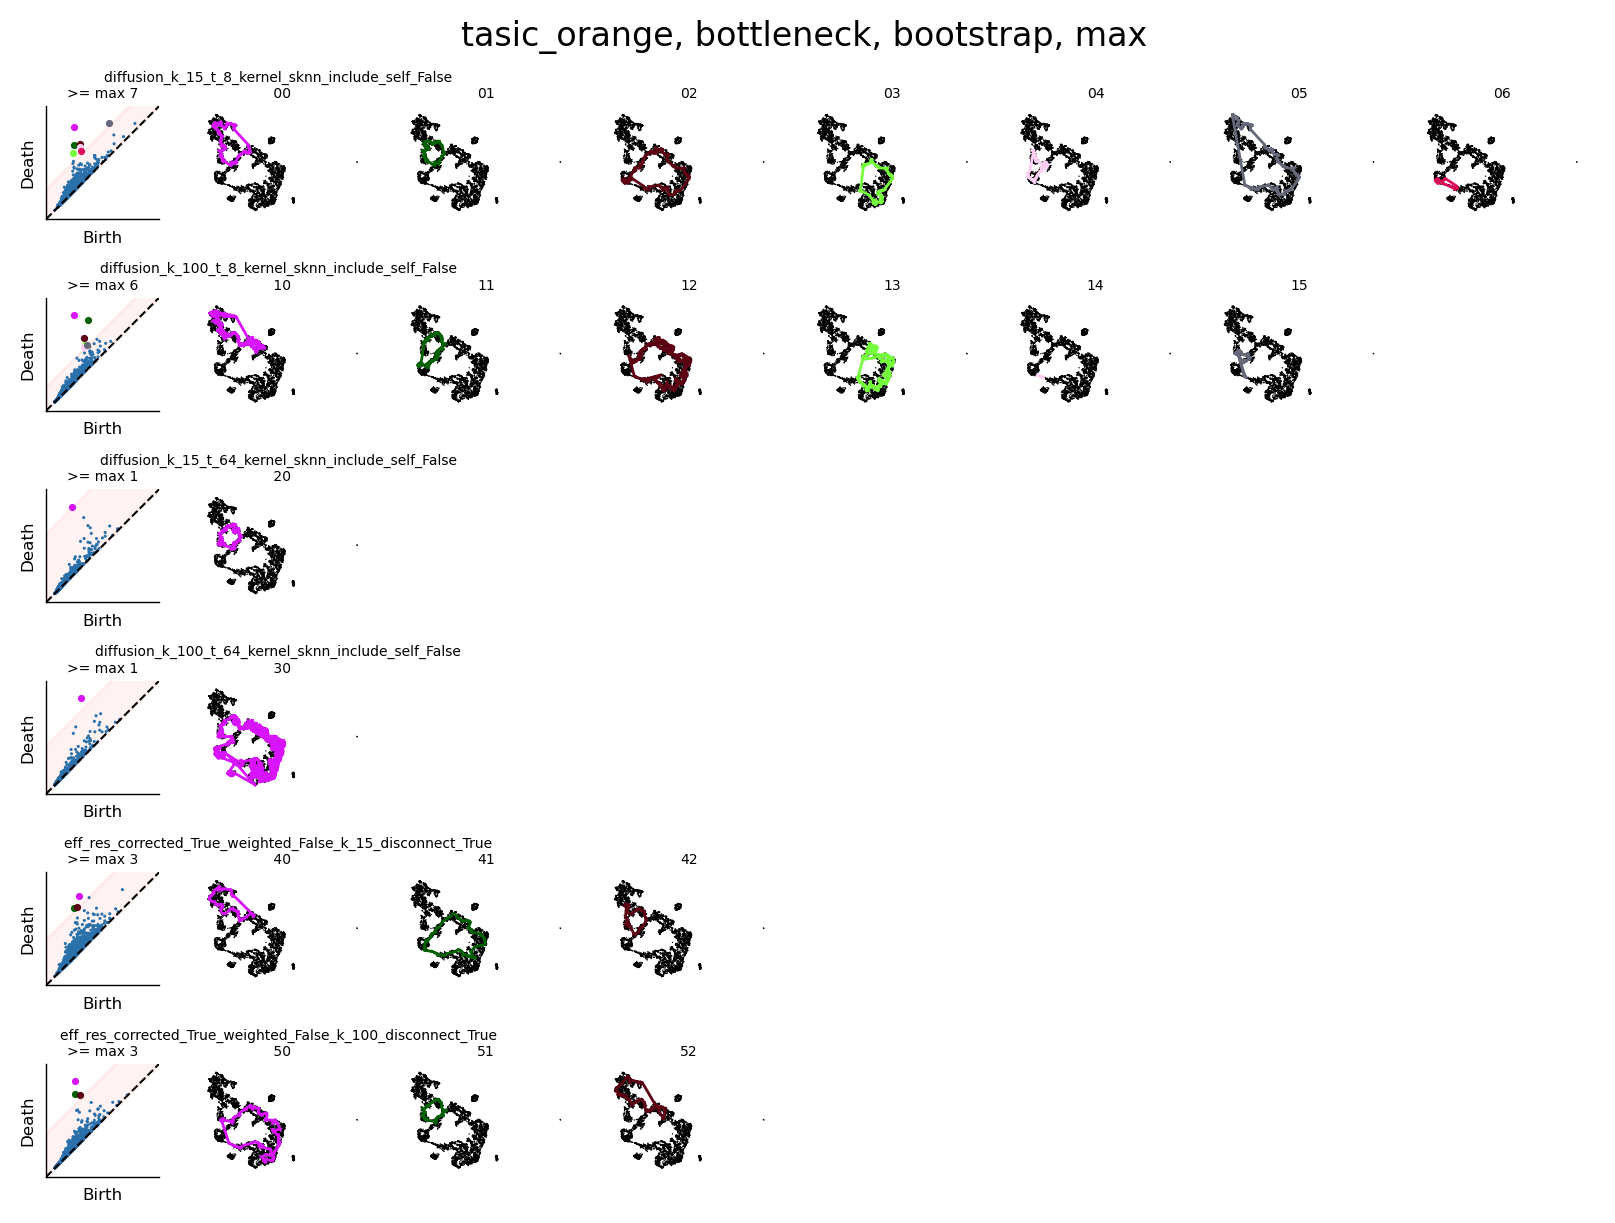

In [ ]:
geq_maxs = fig_bottleneck_max(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="bootstrap", save = True)

# save distribution dist

In [ ]:
_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_orange = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [ ]:
tasic_orange_dict = distribution_max(all_res, cell_group_name= "tasic_orange", clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)

In [ ]:
tasic_orange_dict["idx"]

21

In [ ]:
save_dict(tasic_orange_dict, os.path.join(get_path("data"),"final_dist_bottleneck_max", "dist_tasic_orange.pkl"))

# fig_bottleneck_median

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


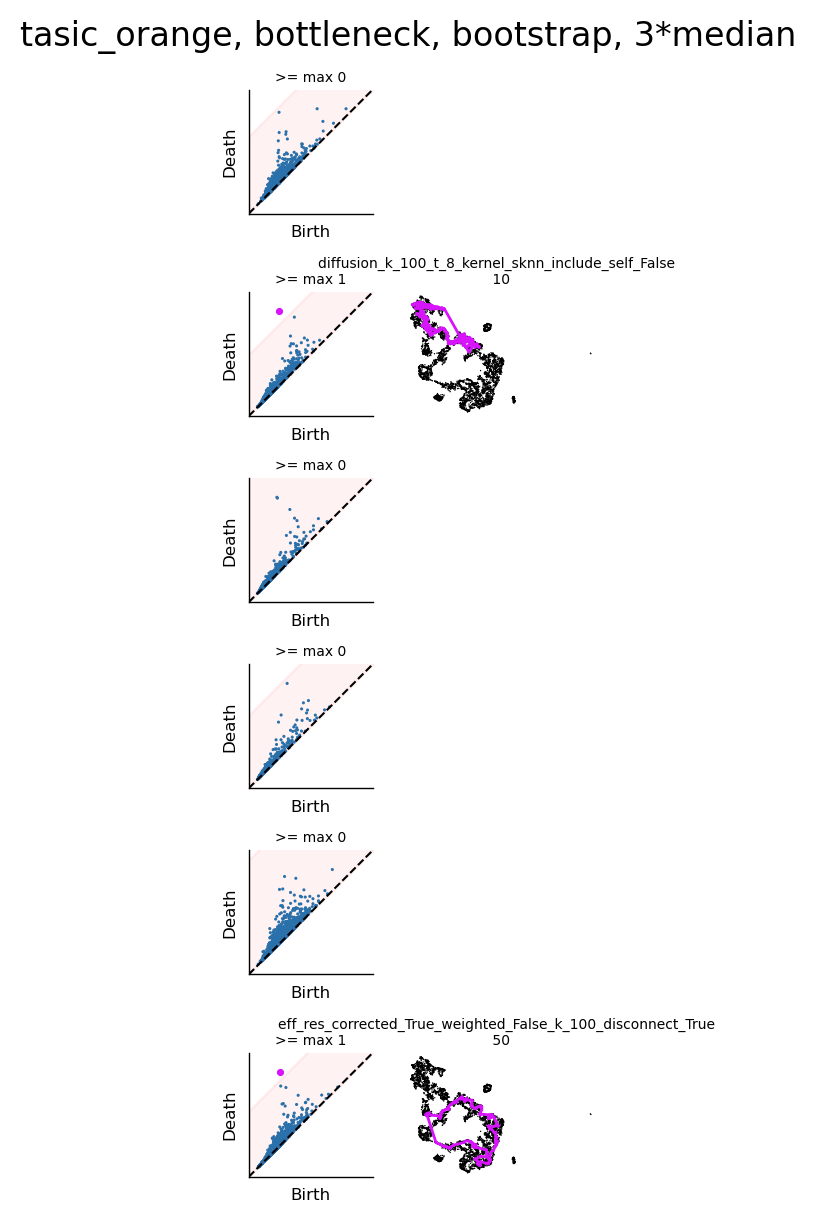

In [ ]:
dataset = "tasic_orange"
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_orange = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

mask_Pvalb = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Pvalb")
mask_Sst = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sst")
mask_orange = np.maximum(mask_Pvalb, mask_Sst)

all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_median(all_res, dataset=dataset, embd_n_mask =  embd_tasic_orange, method="bootstrap", scale = 3, save = False)
dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_tasic_orange_scale_3.pkl"))

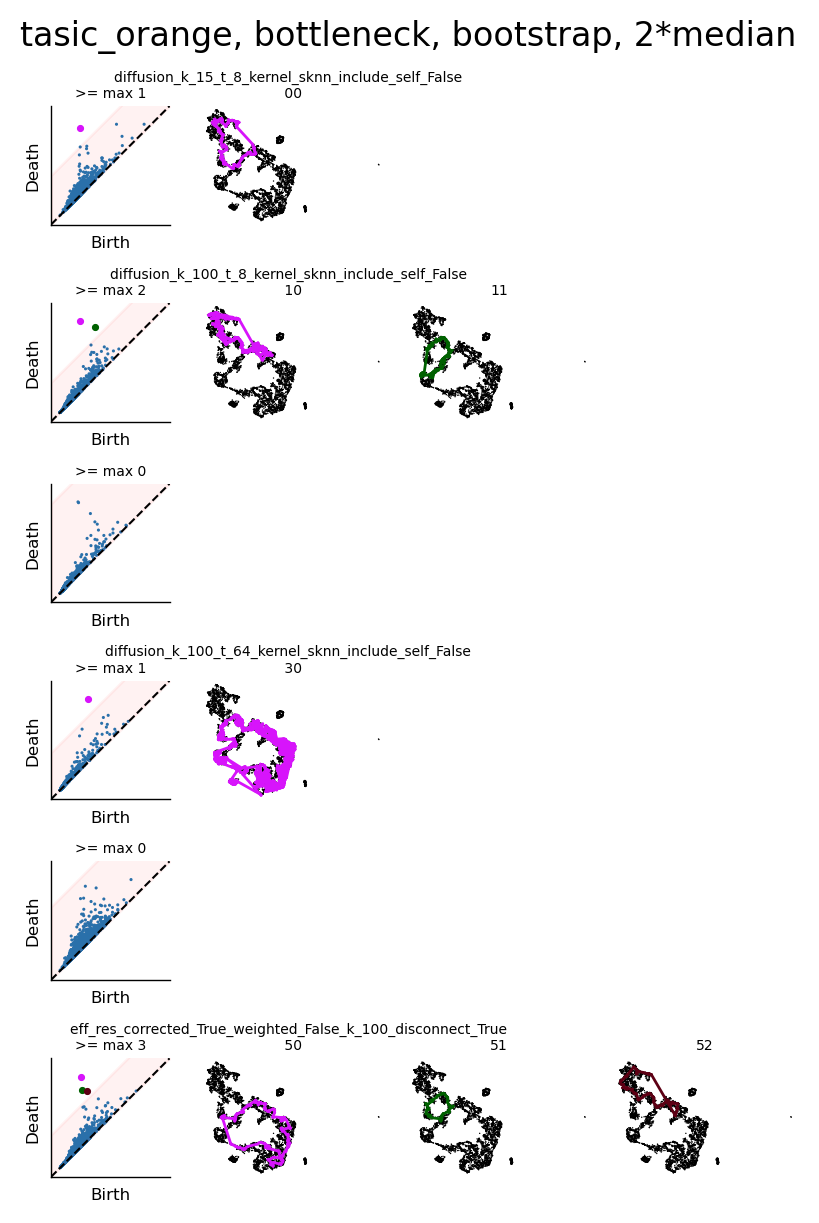

In [ ]:
geq_maxs = fig_bottleneck_median(all_res, dataset=dataset, embd_n_mask =  embd_tasic_orange, method="bootstrap", scale = 2, save = False)
dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_orange, full_d = full_d, mask = mask_orange, geq_maxs = geq_maxs)
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_tasic_orange_scale_2.pkl"))

# fig_bottleneck_std

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


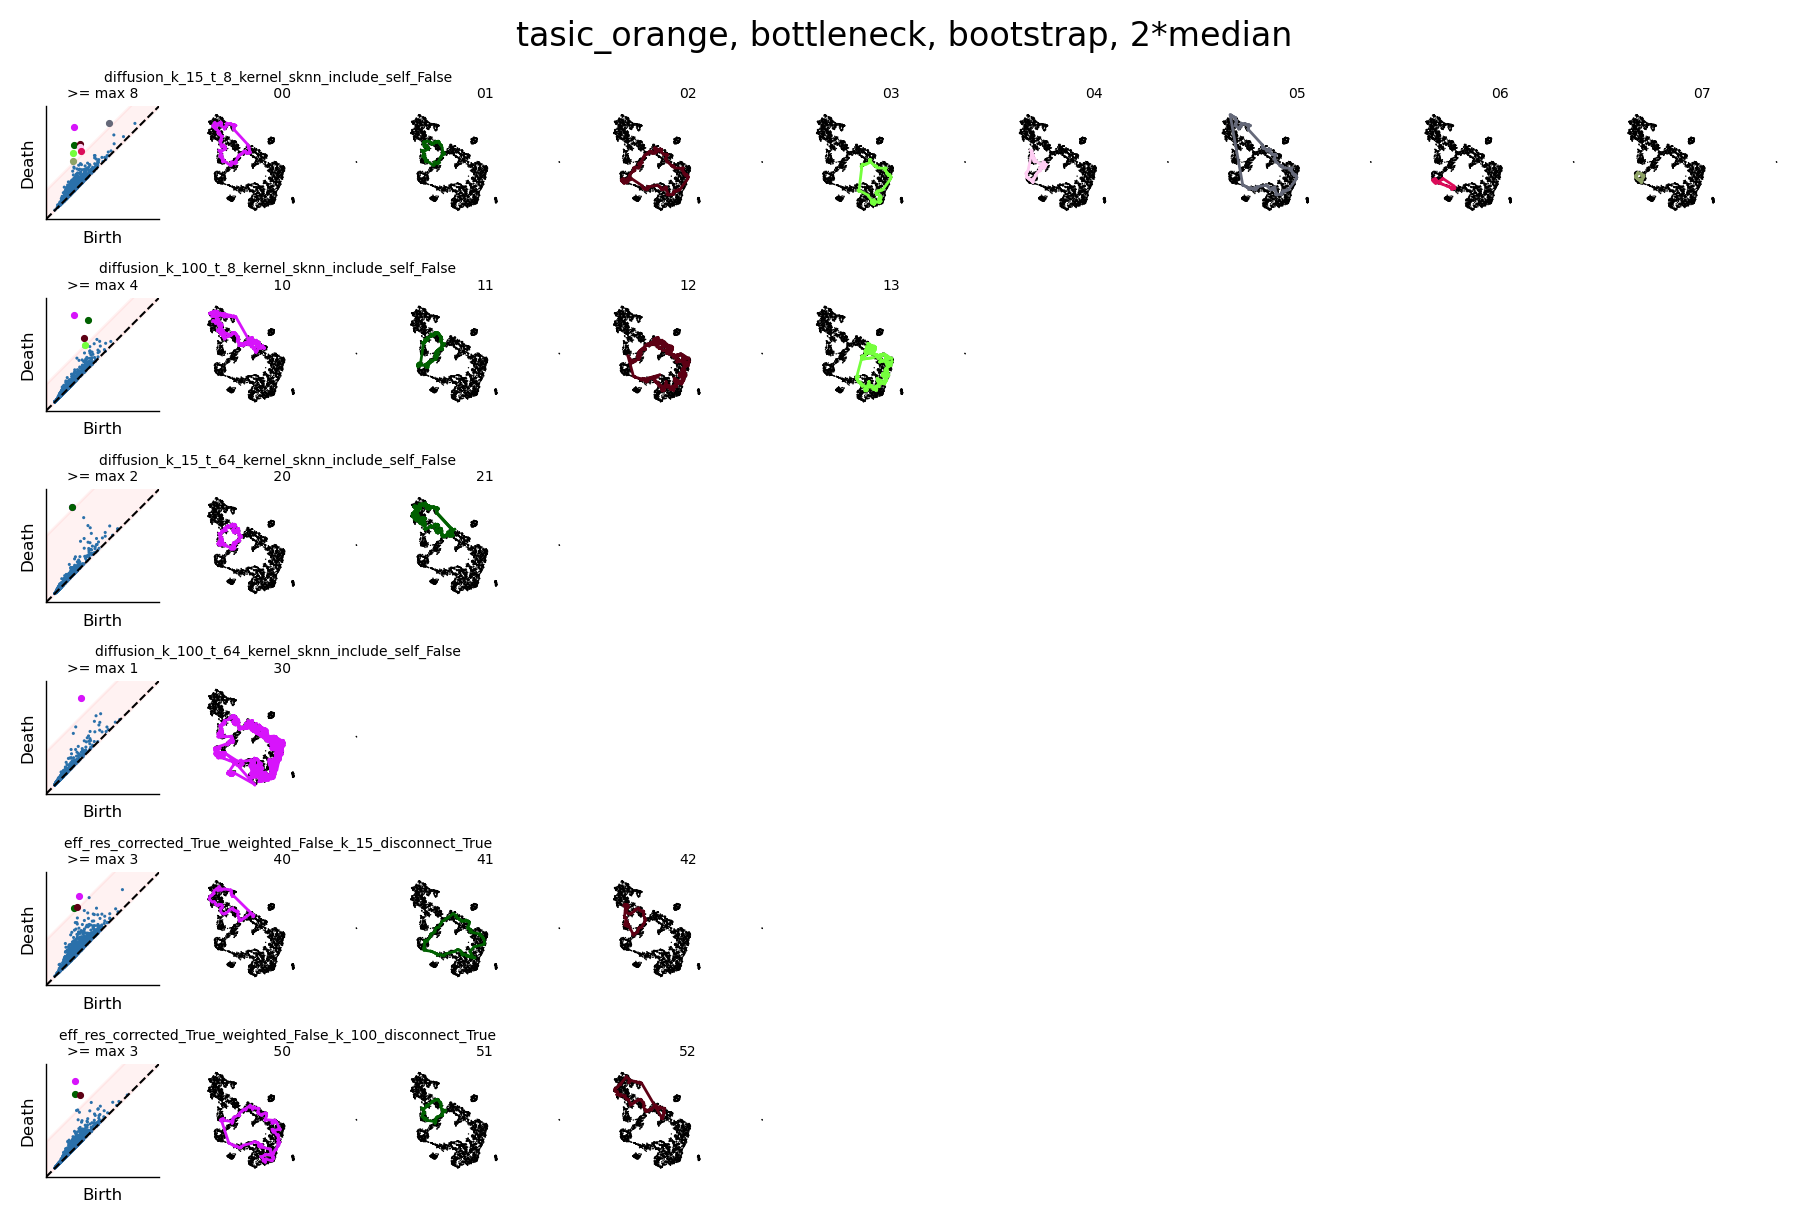

In [ ]:
dataset = "tasic_orange"
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_orange = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

mask_Pvalb = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Pvalb")
mask_Sst = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sst")
mask_orange = np.maximum(mask_Pvalb, mask_Sst)

all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
geq_maxs = fig_bottleneck_std(all_res, dataset=dataset, embd_n_mask =  embd_tasic_orange, method="bootstrap", scale = 2, save = False)